# Multi-Regional Model for Paragliding Flyability Prediction

## Introduction

### The Problem
Paragliding conditions vary significantly across different geographical regions. What makes a location flyable in the Alps may differ from what works in the Dolomites or other mountain areas. A single global model may not capture these regional variations effectively.

### The Multi-Regional Approach
This notebook implements a **multi-regional neural network** that adapts its predictions to geographical regions through:

1. **Geographical Clustering**: Grouping nearby cells into regions using K-means
2. **Regional Embeddings**: Learnable vector representations for each region
3. **Regional Attention**: Attention mechanism that adapts shared features to region-specific patterns
4. **Confidence Weighting**: Weighting training samples by label confidence

### Architecture Overview

```
Input Features
       ↓
Shared Backbone (128 → 64 → 32)
       ↓
Regional Attention (adapts features per region)
       ↓
Classifier (32 → 1)
       ↓
Flyability Probability
```

### Key Benefits
- **Regional Adaptation**: Model learns region-specific weather patterns
- **Data Efficiency**: Shares knowledge across regions while allowing specialization
- **Interpretability**: Can analyze performance per region

---

## 1. Setup

Import the multi-regional module and configure the experiment.

In [2]:
# Import the multi-regional module
from paraglideml.multiregional import (
    MultiRegionalConfig,
    MultiRegionalModel,
    MultiRegionalTrainer,
    load_and_prepare_data,
    create_data_loaders,
    create_weighted_bce_loss,
    find_optimal_threshold,
    evaluate_by_regions,
    evaluate_per_cell,
    plot_training_history,
    plot_threshold_analysis,
    plot_confusion_matrix,
    plot_per_region_performance,
    ExperimentSaver,
    get_next_experiment_dir
)

# Standard imports
import pandas as pd
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Multi-regional module loaded successfully!")

Multi-regional module loaded successfully!


In [43]:
# Configure the experiment
config = MultiRegionalConfig(
    num_regions=20,           # Number of geographical regions
    regional_embedding_dim=32,  # Dimension of regional embeddings
    learning_rate=0.001,     # Learning rate
    dropout_rate=0.3,        # Dropout rate
    batch_size=32,           # Batch size
    epochs=150,              # Maximum epochs
    patience=25,             # Early stopping patience
    val_split=0.2,           # Validation split ratio
    use_confidence_weighting=True  # Use confidence-weighted loss
)

print("Configuration:")
print(f"  Regions: {config.num_regions}")
print(f"  Embedding dim: {config.regional_embedding_dim}")
print(f"  Learning rate: {config.learning_rate}")
print(f"  Dropout: {config.dropout_rate}")

Configuration:
  Regions: 20
  Embedding dim: 32
  Learning rate: 0.001
  Dropout: 0.3


## 2. Data Loading & Preparation

Load the multi-cell dataset and perform geographical clustering.

In [44]:
# Load and prepare data
train_df, test_df, feature_names, region_mapping = load_and_prepare_data(config)

print(f"\nFeature names ({len(feature_names)}):")
print(feature_names)

Performing geographical clustering into 20 regions...
Loaded multicell dataset:
  Train: 22320 samples (45 cells, 20 regions)
  Test:  5580 samples (45 cells, 20 regions)
  Train balance: 53.4% flyable
  Test balance:  53.7% flyable
  Features: 36

Feature names (36):
['is_weekend', 'surface_pressure', 'temp_2m', 'u_10m', 'v_10m', 'wind_speed_10m', 'wind_speed_850', 'wind_speed_700', 'wind_shear_low', 'dps_850', 'dps_700', 'cape', 'cin', 'total_cloud_cover', 'ws_1000', 'lr_1000_975', 'ws_975', 'lr_975_950', 'ws_950', 'lr_950_925', 'ws_925', 'lr_925_900', 'ws_900', 'lr_900_850', 'ws_850', 'lr_850_800', 'ws_800', 'lr_800_750', 'ws_750', 'lr_750_700', 'ws_700', 'lr_700_600', 'ws_600', 'lr_600_500', 'ws_500', 'day_of_year']


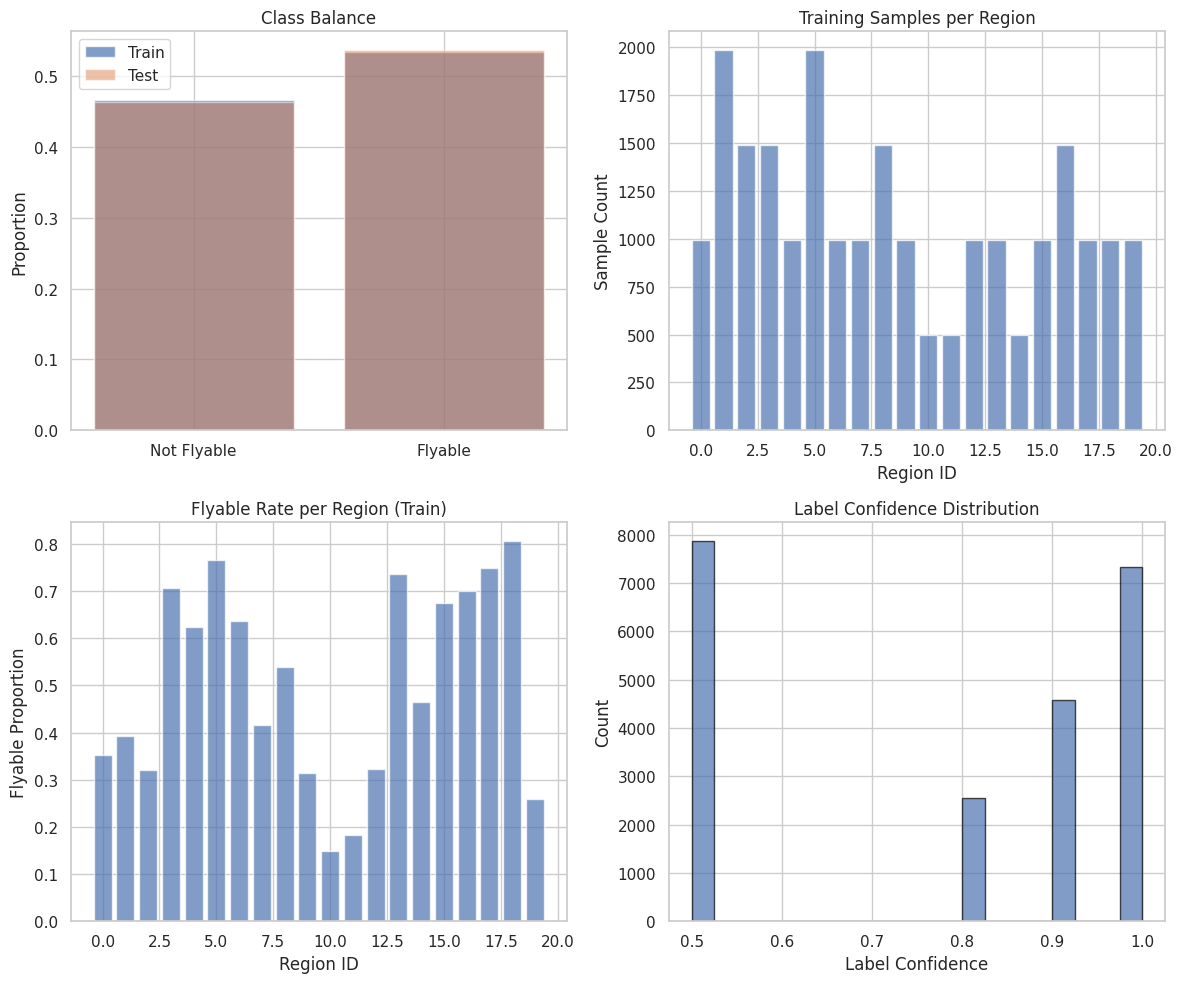

In [45]:
# Visualize data distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Class balance
train_balance = train_df['is_flyable'].value_counts(normalize=True)
test_balance = test_df['is_flyable'].value_counts(normalize=True)
axes[0, 0].bar(['Not Flyable', 'Flyable'], [train_balance[0], train_balance[1]], alpha=0.7, label='Train')
axes[0, 0].bar(['Not Flyable', 'Flyable'], [test_balance[0], test_balance[1]], alpha=0.5, label='Test')
axes[0, 0].set_ylabel('Proportion')
axes[0, 0].set_title('Class Balance')
axes[0, 0].legend()

# Region distribution
region_counts_train = train_df['region_id'].value_counts().sort_index()
axes[0, 1].bar(region_counts_train.index, region_counts_train.values, alpha=0.7)
axes[0, 1].set_xlabel('Region ID')
axes[0, 1].set_ylabel('Sample Count')
axes[0, 1].set_title('Training Samples per Region')

# Region balance (train)
region_flyable = []
for r in sorted(train_df['region_id'].unique()):
    r_df = train_df[train_df['region_id'] == r]
    region_flyable.append(r_df['is_flyable'].mean())
axes[1, 0].bar(sorted(train_df['region_id'].unique()), region_flyable, alpha=0.7)
axes[1, 0].set_xlabel('Region ID')
axes[1, 0].set_ylabel('Flyable Proportion')
axes[1, 0].set_title('Flyable Rate per Region (Train)')

# Confidence weight distribution
axes[1, 1].hist(train_df['label_confidence'], bins=20, alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Label Confidence')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Label Confidence Distribution')

plt.tight_layout()
plt.show()

In [46]:
# Show region mapping
print("Region Mapping (cell_id → region_id):")
for cell_id in sorted(region_mapping.keys())[:20]:
    print(f"  {cell_id}: Region {region_mapping[cell_id]}")
if len(region_mapping) > 20:
    print(f"  ... and {len(region_mapping) - 20} more cells")

Region Mapping (cell_id → region_id):
  43_10: Region 2
  43_11: Region 2
  43_12: Region 12
  43_13: Region 12
  44_10: Region 8
  44_11: Region 2
  44_7: Region 3
  44_9: Region 8
  45_10: Region 5
  45_11: Region 5
  45_13: Region 7
  45_14: Region 7
  45_6: Region 18
  45_7: Region 3
  45_8: Region 3
  45_9: Region 8
  46_10: Region 5
  46_11: Region 5
  46_12: Region 16
  46_13: Region 15
  ... and 25 more cells


## 3. Model Architecture

Create the multi-regional model and inspect its structure.

In [47]:
# Create model
model = MultiRegionalModel(
    input_dim=len(feature_names),
    num_regions=config.num_regions,
    embedding_dim=config.regional_embedding_dim,
    dropout_rate=config.dropout_rate
)

print(f"Multi-Regional Model:")
print(f"  Input features: {len(feature_names)}")
print(f"  Number of regions: {config.num_regions}")
print(f"  Regional embedding dim: {config.regional_embedding_dim}")
print(f"  Total parameters: {model.get_num_parameters():,}")
print(f"\nModel structure:")
print(model)

Multi-Regional Model:
  Input features: 36
  Number of regions: 20
  Regional embedding dim: 32
  Total parameters: 20,481

Model structure:
MultiRegionalModel(
  (backbone): Sequential(
    (0): Linear(in_features=36, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
  )
  (regional_attention): RegionalAttention(
    (attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
    )
    (region_

## 4. Training Setup

Prepare data loaders, loss function, optimizer, and trainer.

In [48]:
# Create data loaders
train_loader, val_loader, scaler, X_train, y_train, region_train, conf_train, \
X_test, y_test, region_test, conf_test = create_data_loaders(
    train_df, test_df, feature_names, config
)

print("Data loaders created successfully!")

Data splits:
  Train: 17856 samples
  Val:   4464 samples
  Test:  5580 samples
Data loaders created successfully!


In [49]:
# Create weighted loss function
criterion = create_weighted_bce_loss(
    y_train, 
    use_confidence=config.use_confidence_weighting
)

# Calculate class ratio for reference
num_pos = int(y_train.sum())
num_neg = len(y_train) - num_pos
pos_weight = num_neg / num_pos if num_pos > 0 else 1.0

print(f"Loss configuration:")
print(f"  Positive samples: {num_pos}")
print(f"  Negative samples: {num_neg}")
print(f"  Class ratio (neg/pos): {pos_weight:.2f}")
print(f"  Confidence weighting: {config.use_confidence_weighting}")

Loss configuration:
  Positive samples: 11910
  Negative samples: 10410
  Class ratio (neg/pos): 0.87
  Confidence weighting: True


In [50]:
# Create optimizer
optimizer = optim.Adam(
    model.parameters(), 
    lr=config.learning_rate, 
    weight_decay=1e-4
)

# Create trainer
trainer = MultiRegionalTrainer(model, config, criterion, optimizer)

print("Trainer initialized!")
print(f"  Optimizer: Adam (lr={config.learning_rate}, weight_decay=1e-4)")

Trainer initialized!
  Optimizer: Adam (lr=0.001, weight_decay=1e-4)


## 5. Training

Train the model with early stopping and visualize the learning curves.

In [51]:
# Train the model
trainer.fit(train_loader, val_loader, verbose=True)

print("\nTraining complete!")

Training for max 150 epochs (patience=25)...
  Using confidence-weighted loss
  Epoch 10/150: train_loss=0.3054, val_loss=0.2968
  Epoch 20/150: train_loss=0.2960, val_loss=0.2934
  Epoch 30/150: train_loss=0.2884, val_loss=0.2879
  Epoch 40/150: train_loss=0.2854, val_loss=0.2901
  Epoch 50/150: train_loss=0.2845, val_loss=0.2896
  Early stopping at epoch 58. Best val_loss: 0.2805
  Training complete. Epochs: 57, Best val_loss: 0.2805

Training complete!


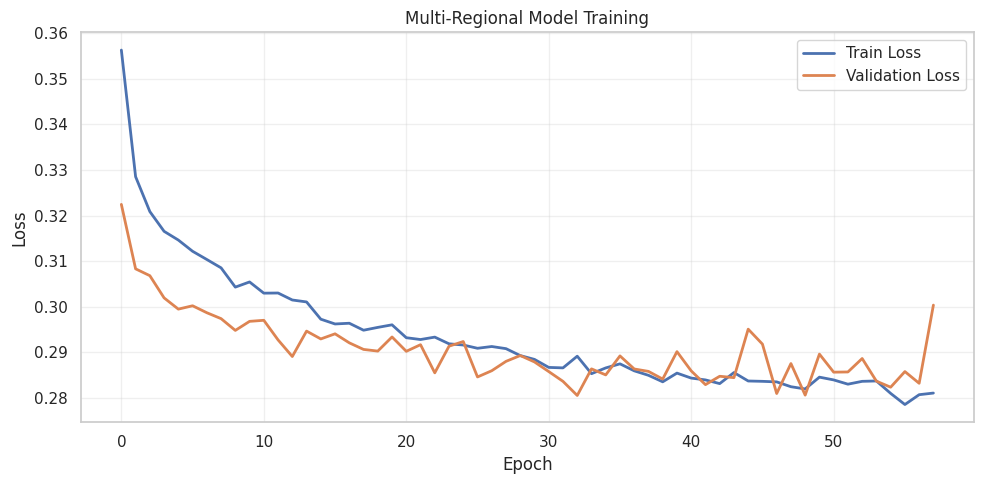

In [52]:
# Plot training history
plot_training_history(trainer.history, title="Multi-Regional Model Training")

## 6. Evaluation

Evaluate the model on test data with optimal threshold selection.

In [53]:
# Make predictions on test set
probs = trainer.predict(X_test, region_test)

print(f"Predictions generated for {len(probs)} test samples")
print(f"  Mean probability: {probs.mean():.3f}")
print(f"  Min/Max: {probs.min():.3f} / {probs.max():.3f}")

Predictions generated for 5580 test samples
  Mean probability: 0.634
  Min/Max: 0.002 / 0.996


In [54]:
# Find optimal threshold
best_threshold, best_macro_f1, threshold_history = find_optimal_threshold(y_test, probs)

best_idx = np.argmax(threshold_history['macro_f1'])

print(f"=== Optimal Threshold Search (by Macro F1) ===")
print(f"Best threshold: {best_threshold:.2f}")
print(f"Macro F1: {best_macro_f1:.3f}")
print(f"  F1 (Not Flyable): {threshold_history['f1_not_flyable'][best_idx]:.3f}")
print(f"  F1 (Flyable):     {threshold_history['f1_flyable'][best_idx]:.3f}")

=== Optimal Threshold Search (by Macro F1) ===
Best threshold: 0.70
Macro F1: 0.794
  F1 (Not Flyable): 0.778
  F1 (Flyable):     0.811


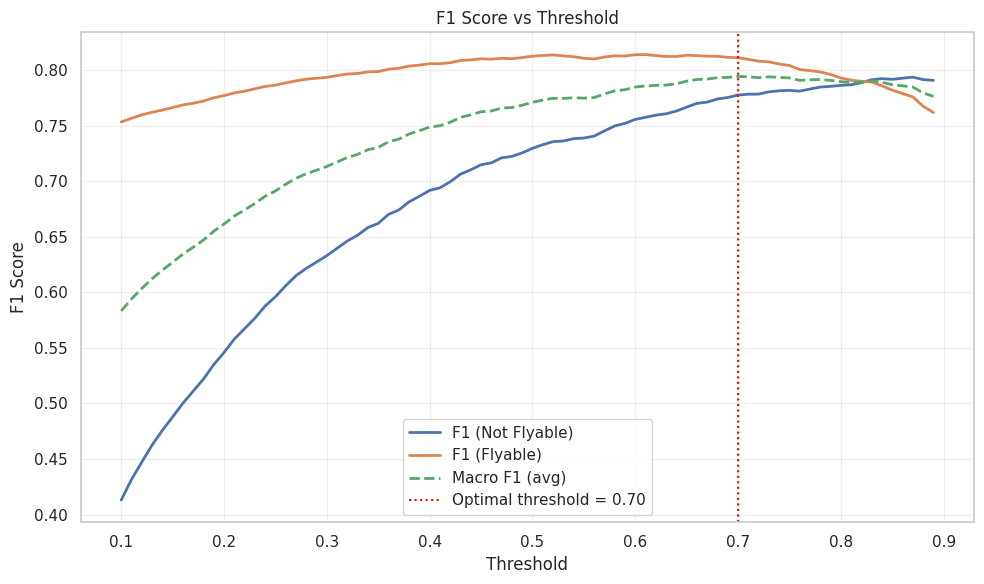

In [55]:
# Plot threshold analysis
plot_threshold_analysis(y_test, probs, best_threshold)

In [56]:
# Apply optimal threshold and get classification report
y_pred = (probs > best_threshold).astype(float)

print("\n" + "="*50)
print(f"CLASSIFICATION REPORT (threshold={best_threshold:.2f})")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Not Flyable', 'Flyable']))


CLASSIFICATION REPORT (threshold=0.70)
              precision    recall  f1-score   support

 Not Flyable       0.78      0.77      0.78      2586
     Flyable       0.80      0.82      0.81      2994

    accuracy                           0.80      5580
   macro avg       0.79      0.79      0.79      5580
weighted avg       0.80      0.80      0.80      5580



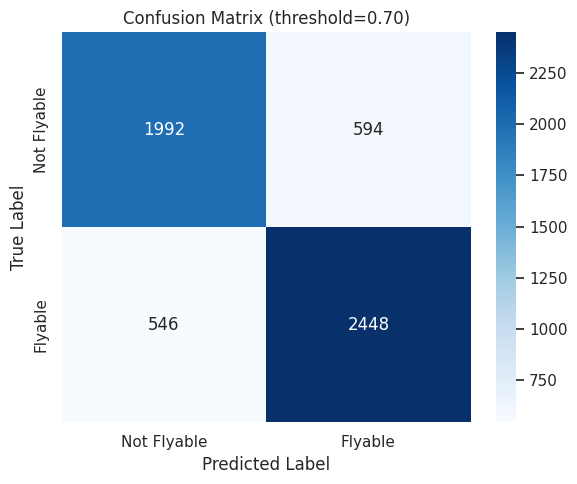

In [57]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, ['Not Flyable', 'Flyable'], title=f'Confusion Matrix (threshold={best_threshold:.2f})')

## 7. Per-Region Analysis

Analyze model performance across different geographical regions.

In [58]:
# Create test loader and region names
from paraglideml.multiregional import RegionalFlyableDataset
from torch.utils.data import DataLoader

test_loader_for_region = DataLoader(
    RegionalFlyableDataset(X_test, y_test, region_test, conf_test),
    batch_size=config.batch_size
)

region_names = {i: f'Region_{i}' for i in range(config.num_regions)}

# Evaluate by regions
region_results = evaluate_by_regions(model, test_loader_for_region, region_names)

# Print per-region statistics
print("\n" + "="*60)
print("PER-REGION PERFORMANCE")
print("="*60)

for region_name, results in region_results.items():
    if len(results['y_true']) > 0:
        from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
        y_true = results['y_true']
        y_pred = results['y_pred']
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        
        print(f"\n{region_name}:")
        print(f"  Samples: {len(y_true)}")
        print(f"  Accuracy:  {acc:.3f}")
        print(f"  Precision: {precision:.3f}")
        print(f"  Recall:    {recall:.3f}")
        print(f"  F1:        {f1:.3f}")


PER-REGION PERFORMANCE

Region_0:
  Samples: 248
  Accuracy:  0.798
  Precision: 0.636
  Recall:    0.875
  F1:        0.737

Region_1:
  Samples: 496
  Accuracy:  0.817
  Precision: 0.788
  Recall:    0.777
  F1:        0.783

Region_2:
  Samples: 372
  Accuracy:  0.739
  Precision: 0.541
  Recall:    0.734
  F1:        0.623

Region_3:
  Samples: 372
  Accuracy:  0.790
  Precision: 0.778
  Recall:    0.993
  F1:        0.872

Region_4:
  Samples: 248
  Accuracy:  0.710
  Precision: 0.675
  Recall:    0.936
  F1:        0.784

Region_5:
  Samples: 496
  Accuracy:  0.825
  Precision: 0.829
  Recall:    0.974
  F1:        0.896

Region_6:
  Samples: 248
  Accuracy:  0.778
  Precision: 0.757
  Recall:    0.941
  F1:        0.839

Region_7:
  Samples: 248
  Accuracy:  0.714
  Precision: 0.780
  Recall:    0.547
  F1:        0.643

Region_8:
  Samples: 372
  Accuracy:  0.726
  Precision: 0.684
  Recall:    0.972
  F1:        0.803

Region_9:
  Samples: 248
  Accuracy:  0.790
  Precision: 

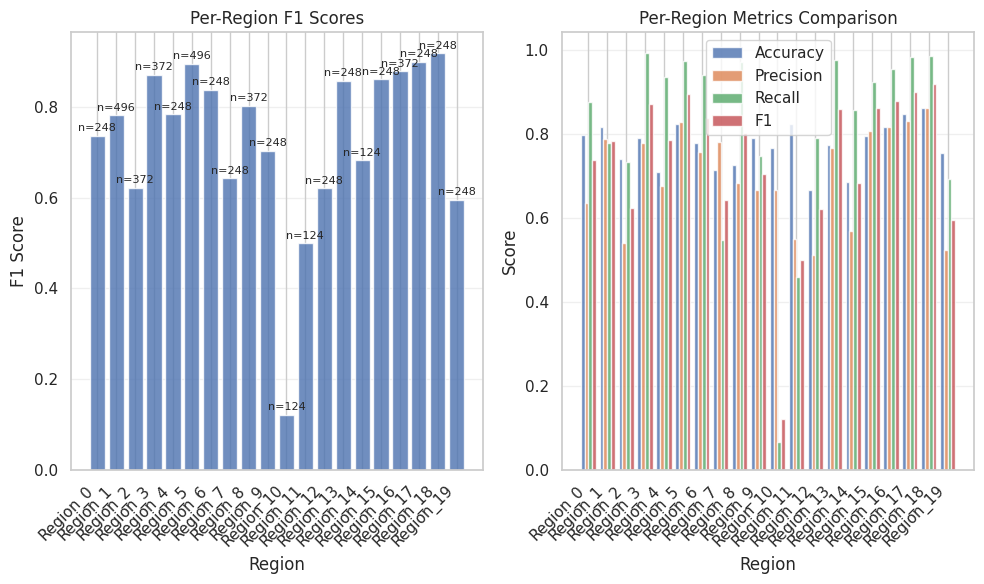

In [59]:
# Plot per-region performance
plot_per_region_performance(region_results)

In [60]:
# Per-cell analysis with both thresholds
# Make sure we have predictions
df_results = test_df.copy()
df_results['prob'] = probs
# Create predictions from probabilities (using best_threshold from previous cell)
df_results['pred'] = (probs > best_threshold).astype(float)

cell_stats = evaluate_per_cell(df_results)

# Calculate per-cell optimal threshold
from sklearn.metrics import f1_score

per_cell_thresholds = []
for cell_id in df_results['cell_id'].unique():
    cell_data = df_results[df_results['cell_id'] == cell_id]
    cell_probs = cell_data['prob'].values
    cell_true = cell_data['is_flyable'].values
    
    # Skip cells with no positive examples
    if cell_true.sum() == 0:
        continue
    
    # Find optimal threshold for this cell
    thresholds = np.arange(0.1, 0.9, 0.01)
    f1_scores = [f1_score(cell_true, (cell_probs > t).astype(float), zero_division=0) for t in thresholds]
    best_idx = np.argmax(f1_scores)
    best_cell_thresh = thresholds[best_idx]
    best_cell_f1 = f1_scores[best_idx]
    
    # Calculate F1 with global threshold
    global_f1 = f1_score(cell_true, (cell_probs > best_threshold).astype(float), zero_division=0)
    
    # Get region_id
    region_id = cell_data['region_id'].iloc[0]
    
    per_cell_thresholds.append({
        'cell_id': cell_id,
        'region_id': region_id,
        'samples': len(cell_data),
        'global_threshold': best_threshold,
        'global_f1': global_f1,
        'optimal_threshold': best_cell_thresh,
        'optimal_f1': best_cell_f1,
        'f1_delta': best_cell_f1 - global_f1
    })

cell_threshold_stats = pd.DataFrame(per_cell_thresholds).sort_values('optimal_f1', ascending=False)

print("\n" + "="*80)
print("PER-CELL PERFORMANCE: Global vs Optimal Threshold")
print("="*80)
print(cell_threshold_stats.head(30).to_string(index=False))

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"Global threshold: {best_threshold:.3f}")
print(f"Mean per-cell optimal threshold: {cell_threshold_stats['optimal_threshold'].mean():.3f} (±{cell_threshold_stats['optimal_threshold'].std():.3f})")
print(f"Mean global F1: {cell_threshold_stats['global_f1'].mean():.3f}")
print(f"Mean optimal F1: {cell_threshold_stats['optimal_f1'].mean():.3f}")
print(f"Mean F1 gain: {cell_threshold_stats['f1_delta'].mean():.3f}")
print(f"Max F1 gain: {cell_threshold_stats['f1_delta'].max():.3f} (cell: {cell_threshold_stats.loc[cell_threshold_stats['f1_delta'].idxmax(), 'cell_id']})")


PER-CELL PERFORMANCE: Global vs Optimal Threshold
cell_id  region_id  samples  global_threshold  global_f1  optimal_threshold  optimal_f1  f1_delta
   45_7          3      124               0.7   0.962963               0.77    0.967442  0.004479
  45_11          5      124               0.7   0.950226               0.22    0.960699  0.010472
   45_6         18      124               0.7   0.936364               0.88    0.947867  0.011504
   46_6         18      124               0.7   0.910000               0.88    0.946809  0.036809
  46_12         16      124               0.7   0.902564               0.32    0.939535  0.036971
  46_11          5      124               0.7   0.910000               0.36    0.938967  0.028967
  46_13         15      124               0.7   0.926108               0.52    0.938389  0.012280
   46_7         17      124               0.7   0.919431               0.65    0.929577  0.010146
   47_7         17      124               0.7   0.912500           

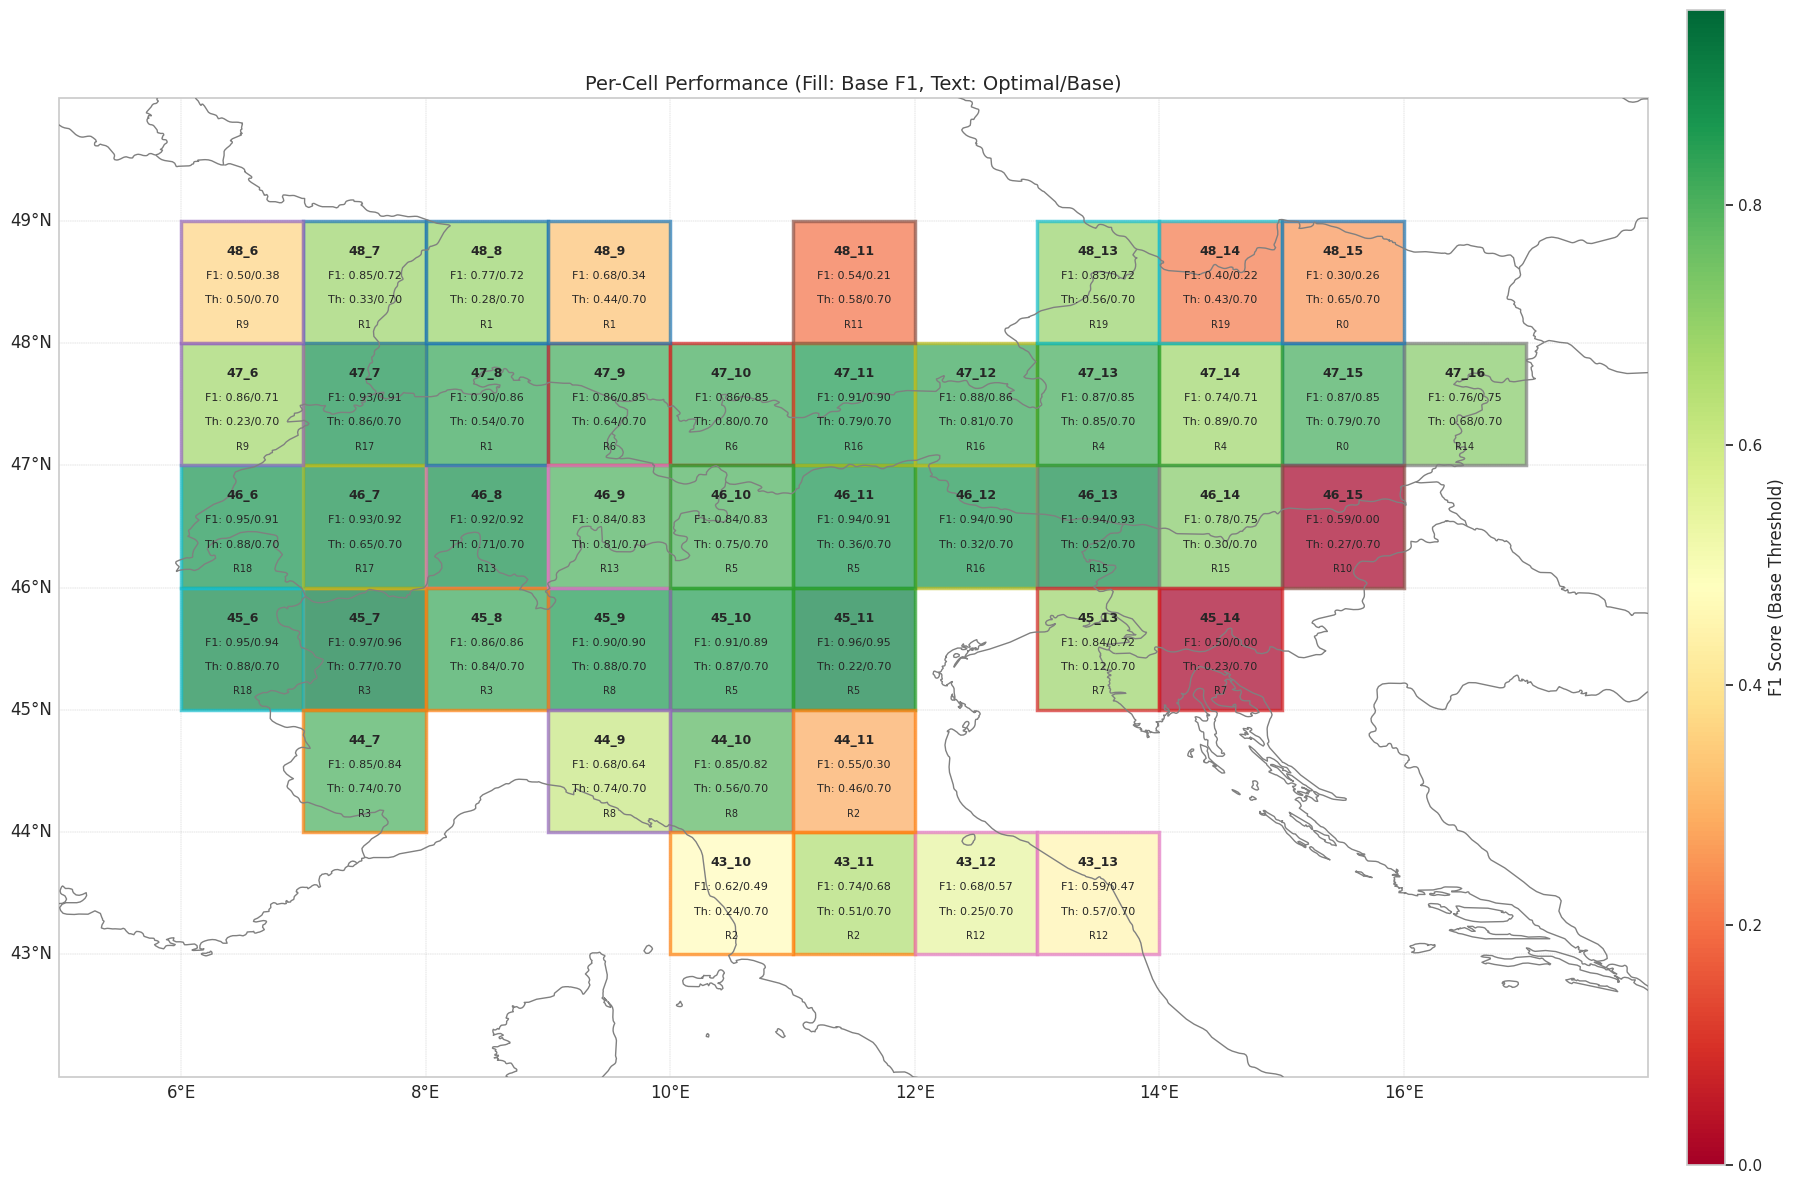

In [61]:
# Per-cell performance map: color by base F1, show both values
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle

# Use cell_threshold_stats which has both F1 values
lats = [int(c.split('_')[0]) for c in cell_threshold_stats['cell_id']]
lons = [int(c.split('_')[1]) for c in cell_threshold_stats['cell_id']]
lat_min, lat_max = min(lats) - 1, max(lats) + 2
lon_min, lon_max = min(lons) - 1, max(lons) + 2

fig = plt.figure(figsize=(20, 12))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Устанавливаем пределы осей
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Границы стран
ax.add_feature(cfeature.BORDERS, linewidth=1, edgecolor='gray', zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='gray', zorder=3)

# Сетка 1 градус
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.MaxNLocator(integer=True)
gl.ylocator = mticker.MaxNLocator(integer=True)

# Рисуем ячейки
for _, row in cell_threshold_stats.iterrows():
    cell_id = row['cell_id']
    lat, lon = map(int, cell_id.split('_'))
    f1_base = row['global_f1']
    f1_opt = row['optimal_f1']
    th_base = row['global_threshold']
    th_opt = row['optimal_threshold']
    region_id = row['region_id']

    # Цвет заливки по base F1
    face_color = plt.cm.RdYlGn(f1_base)

    # Цвет рамки по региону
    edge_color = plt.cm.tab10(region_id / config.num_regions)

    # Рисуем прямоугольник ячейки (с transform!)
    rect = Rectangle((lon, lat), 1, 1,
                     facecolor=face_color,
                     edgecolor=edge_color,
                     linewidth=2.5,
                     alpha=0.7,
                     zorder=2,
                     transform=ccrs.PlateCarree())
    ax.add_patch(rect)

    # Текст внутри ячейки (тоже с transform!)
    ax.text(lon + 0.5, lat + 0.75, cell_id,
            ha='center', va='center', fontsize=9, fontweight='bold', zorder=4,
            transform=ccrs.PlateCarree())
    ax.text(lon + 0.5, lat + 0.55, f"F1: {f1_opt:.2f}/{f1_base:.2f}",
            ha='center', va='center', fontsize=8, zorder=4,
            transform=ccrs.PlateCarree())
    ax.text(lon + 0.5, lat + 0.35, f"Th: {th_opt:.2f}/{th_base:.2f}",
            ha='center', va='center', fontsize=8, zorder=4,
            transform=ccrs.PlateCarree())
    ax.text(lon + 0.5, lat + 0.15, f"R{region_id}",
            ha='center', va='center', fontsize=7, zorder=4,
            transform=ccrs.PlateCarree())

# Colorbar для F1 (base)
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn,
                            norm=plt.Normalize(vmin=cell_threshold_stats['global_f1'].min(),
                                             vmax=cell_threshold_stats['global_f1'].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02, aspect=30)
cbar.set_label('F1 Score (Base Threshold)', fontsize=12)

plt.title("Per-Cell Performance (Fill: Base F1, Text: Optimal/Base)", fontsize=14)
plt.tight_layout()
plt.show()

PER-REGION PROBABILITY CALIBRATION

Region 0:
  Samples: 248
  Temperature: 1.000 (no change)
  ECE before: 0.1492
  ECE after:  0.1492
  Improvement: -0.0000

Region 1:
  Samples: 496
  Temperature: 1.000 (no change)
  ECE before: 0.0413
  ECE after:  0.0413
  Improvement: +0.0000

Region 2:
  Samples: 372
  Temperature: 1.000 (no change)
  ECE before: 0.1219
  ECE after:  0.1219
  Improvement: +0.0000

Region 3:
  Samples: 372
  Temperature: 1.000 (no change)
  ECE before: 0.1553
  ECE after:  0.1553
  Improvement: +0.0000

Region 4:
  Samples: 248
  Temperature: 1.000 (no change)
  ECE before: 0.2079
  ECE after:  0.2079
  Improvement: +0.0000

Region 5:
  Samples: 496
  Temperature: 1.000 (no change)
  ECE before: 0.0961
  ECE after:  0.0961
  Improvement: +0.0000

Region 6:
  Samples: 248
  Temperature: 1.000 (no change)
  ECE before: 0.1237
  ECE after:  0.1237
  Improvement: -0.0000

Region 7:
  Samples: 248
  Temperature: 1.000 (no change)
  ECE before: 0.1095
  ECE after:  0.1

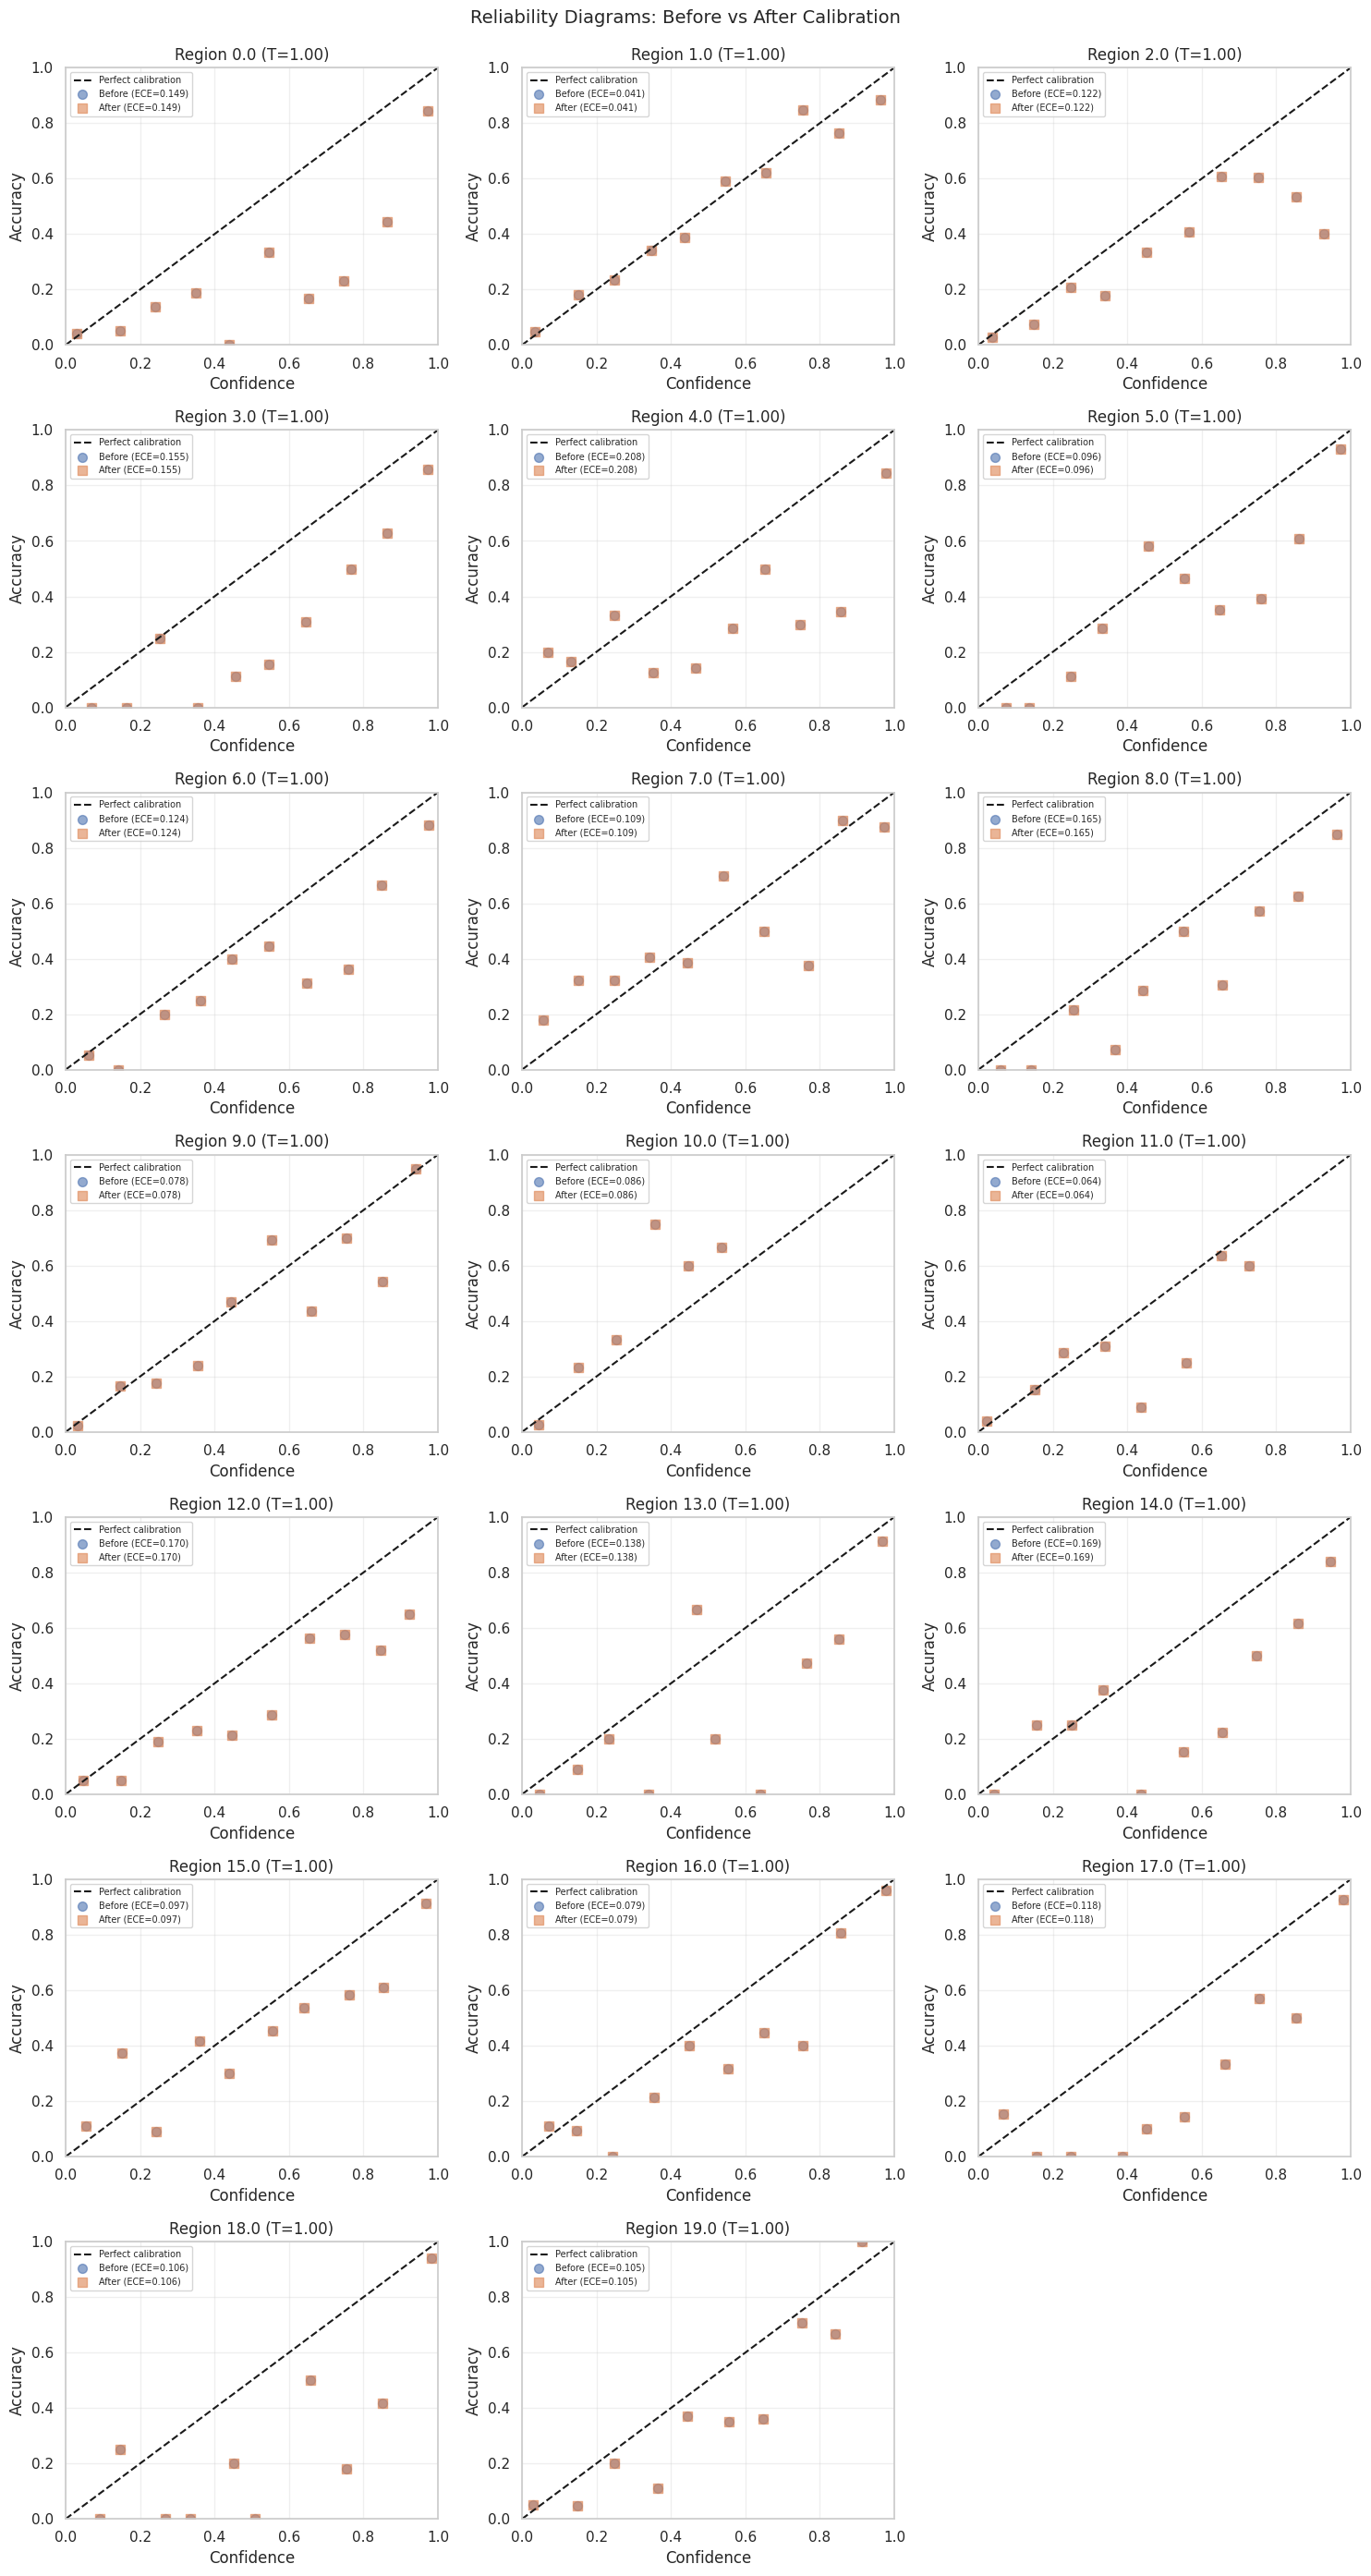


✓ Calibrators trained and stored in 'region_calibrators' dict
  Usage: calibrated_probs = region_calibrators[region_id].calibrate(logits)


In [62]:
# Per-Region Probability Calibration
import torch.nn as nn

# Для нейросети используем температурную калибровку (Temperature Scaling)
# Это simplest метод для deep learning моделей

class TemperatureScaling:
    """
    Temperature Scaling calibration for neural networks.
    
    Learns a single temperature parameter T that divides logits before sigmoid:
        calibrated_prob = sigmoid(logit / T)
    
    T > 1: softens probabilities (makes them less extreme)
    T < 1: sharpens probabilities (makes them more extreme)
    T = 1: no calibration (original probabilities)
    """
    def __init__(self):
        self.temperature = nn.Parameter(torch.ones(1))
        
    def fit(self, logits, true_labels, max_iters=1000, lr=0.01):
        """
        Fit temperature on validation data using negative log likelihood.
        
        Args:
            logits: Raw model outputs (before sigmoid) [n_samples]
            true_labels: Binary labels [n_samples]
        """
        optimizer = optim.LBFGS([self.temperature], lr=lr, max_iter=max_iters)
        
        logits_tensor = torch.FloatTensor(logits).unsqueeze(1)  # [n, 1]
        labels_tensor = torch.FloatTensor(true_labels).unsqueeze(1)  # [n, 1]
        
        def eval_loss():
            temp = self.temperature.unsqueeze(1).t()  # [1, 1]
            scaled_logits = logits_tensor / temp  # [n, 1]
            loss = nn.BCEWithLogitsLoss()(scaled_logits, labels_tensor)
            return loss
        
        optimizer.step(eval_loss)
        return self.temperature.item()
    
    def calibrate(self, logits):
        """Apply temperature scaling to logits."""
        with torch.no_grad():
            temp = self.temperature.item()
            logits_tensor = torch.FloatTensor(logits).unsqueeze(1)
            return torch.sigmoid(logits_tensor / temp).numpy().flatten()


# Collect logits (probabilities → logits via logit transform)
# For binary classification: logit = log(p / (1 - p))
def prob_to_logit(prob):
    """Convert probability to logit with clipping for numerical stability."""
    prob = np.clip(prob, 1e-7, 1 - 1e-7)
    return np.log(prob / (1 - prob))

test_logits = prob_to_logit(probs)

# Fit calibration per region
region_calibrators = {}
calibration_results = []

print("="*70)
print("PER-REGION PROBABILITY CALIBRATION")
print("="*70)

for region_id in sorted(df_results['region_id'].unique()):
    region_mask = df_results['region_id'] == region_id
    region_logits = test_logits[region_mask]
    region_true = y_test[region_mask]
    region_probs = probs[region_mask]
    
    # Skip if too few samples
    if len(region_true) < 50:
        print(f"\nRegion {region_id}: Skipped (only {len(region_true)} samples)")
        continue
    
    # Fit temperature scaling
    calibrator = TemperatureScaling()
    temp = calibrator.fit(region_logits, region_true)
    calibrated_probs = calibrator.calibrate(region_logits)
    
    # Calculate calibration metrics
    # Expected Calibration Error (ECE)
    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece_before = 0
    ece_after = 0
    
    for i in range(n_bins):
        mask = (region_probs > bin_edges[i]) & (region_probs <= bin_edges[i + 1])
        if mask.sum() == 0:
            continue
        acc = region_true[mask].mean()
        conf = region_probs[mask].mean()
        ece_before += (mask.sum() / len(region_true)) * np.abs(acc - conf)
        
        mask_cal = (calibrated_probs > bin_edges[i]) & (calibrated_probs <= bin_edges[i + 1])
        if mask_cal.sum() == 0:
            continue
        acc_cal = region_true[mask_cal].mean()
        conf_cal = calibrated_probs[mask_cal].mean()
        ece_after += (mask_cal.sum() / len(region_true)) * np.abs(acc_cal - conf_cal)
    
    # Store results
    region_calibrators[region_id] = calibrator
    calibration_results.append({
        'region_id': region_id,
        'samples': len(region_true),
        'temperature': temp,
        'ece_before': ece_before,
        'ece_after': ece_after,
        'ece_improvement': ece_before - ece_after
    })
    
    print(f"\nRegion {region_id}:")
    print(f"  Samples: {len(region_true)}")
    print(f"  Temperature: {temp:.3f} " + 
          ("(no change)" if abs(temp - 1.0) < 0.1 else 
           "(softening)" if temp > 1.0 else "(sharpening)"))
    print(f"  ECE before: {ece_before:.4f}")
    print(f"  ECE after:  {ece_after:.4f}")
    print(f"  Improvement: {ece_before - ece_after:+.4f}")

# Summary
calib_df = pd.DataFrame(calibration_results)

print("\n" + "="*70)
print("CALIBRATION SUMMARY")
print("="*70)
print(f"Regions calibrated: {len(calib_df)}")
print(f"Mean temperature: {calib_df['temperature'].mean():.3f} (±{calib_df['temperature'].std():.3f})")
print(f"Mean ECE before:  {calib_df['ece_before'].mean():.4f}")
print(f"Mean ECE after:   {calib_df['ece_after'].mean():.4f}")
print(f"Mean improvement: {calib_df['ece_improvement'].mean():+.4f}")

# Visualization of calibration
n_regions = len(calib_df)
n_cols = min(3, n_regions)
n_rows = (n_regions + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if n_regions == 1:
    axes = np.array([axes])
axes = axes.flatten()

for plot_idx, (idx, row) in enumerate(calib_df.iterrows()):
    region_id = row['region_id']
    ax = axes[plot_idx]
    
    region_mask = df_results['region_id'] == region_id
    region_probs = probs[region_mask]
    region_true = y_test[region_mask]
    region_logits = test_logits[region_mask]
    
    calibrator = region_calibrators[region_id]
    calibrated_probs = calibrator.calibrate(region_logits)
    
    # Plot reliability diagram
    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    
    # Before calibration
    bin_accs_before = []
    bin_confs_before = []
    for i in range(n_bins):
        mask = (region_probs > bin_edges[i]) & (region_probs <= bin_edges[i + 1])
        if mask.sum() > 0:
            bin_accs_before.append(region_true[mask].mean())
            bin_confs_before.append(region_probs[mask].mean())
    
    # After calibration
    bin_accs_after = []
    bin_confs_after = []
    for i in range(n_bins):
        mask = (calibrated_probs > bin_edges[i]) & (calibrated_probs <= bin_edges[i + 1])
        if mask.sum() > 0:
            bin_accs_after.append(region_true[mask].mean())
            bin_confs_after.append(calibrated_probs[mask].mean())
    
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.scatter(bin_confs_before, bin_accs_before, alpha=0.6, s=50, 
               label=f'Before (ECE={row["ece_before"]:.3f})')
    ax.scatter(bin_confs_after, bin_accs_after, alpha=0.6, s=50, marker='s',
               label=f'After (ECE={row["ece_after"]:.3f})')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Region {region_id} (T={row["temperature"]:.2f})')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

# Hide unused subplots
for plot_idx in range(len(calib_df), len(axes)):
    axes[plot_idx].set_visible(False)

plt.suptitle('Reliability Diagrams: Before vs After Calibration', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ Calibrators trained and stored in 'region_calibrators' dict")
print("  Usage: calibrated_probs = region_calibrators[region_id].calibrate(logits)")

## 8. Saving Results (Optional)

Save the trained model and results for future use.

In [142]:
# Create experiment directory
import datetime
exp_dir = get_next_experiment_dir()
print(f"Saving experiment to: {exp_dir}")

# Create saver
saver = ExperimentSaver(exp_dir)

# Save model
saver.save_model(model)
print("  Model saved")

# Save features
saver.save_features(feature_names)
print("  Features saved")

# Save predictions
saved_paths = saver.save_predictions(df_results, best_threshold, config.hysteresis_margin)
print(f"  Predictions saved ({len(saved_paths)} files)")

# Save region mapping
saver.save_region_mapping(region_mapping)
print("  Region mapping saved")

# Save per-cell stats
saver.save_per_cell_stats(cell_stats)
print("  Per-cell stats saved")

# Save configuration and results
y_pred_for_report = df_results['pred'].values
report_metrics = classification_report(y_test, y_pred_for_report, target_names=['Not Flyable', 'Flyable'])

results = {
    'macro_f1': float(best_macro_f1),
    'threshold': float(best_threshold),
    'epochs_trained': trainer.epochs_trained,
    'best_val_loss': float(trainer.best_val_loss),
    'num_parameters': model.get_num_parameters()
}
saver.save_config(config, results)
print("  Config saved")

# Save report
report_text = f"""
Multi-Regional Model Training Report
{'='*50}
Date: {datetime.datetime.now()}

Configuration:
  Number of regions: {config.num_regions}
  Regional embedding dim: {config.regional_embedding_dim}
  Learning rate: {config.learning_rate}
  Dropout rate: {config.dropout_rate}
  Confidence weighting: {config.use_confidence_weighting}

Results:
  Macro F1: {best_macro_f1:.3f}
  Optimal threshold: {best_threshold:.2f}
  Epochs trained: {trainer.epochs_trained}
  Best validation loss: {trainer.best_val_loss:.4f}
  Model parameters: {model.get_num_parameters():,}

{report_metrics}
"""
saver.save_report(report_text)
print("  Report saved")

print(f"\nExperiment saved successfully to {exp_dir}")

Saving experiment to: /home/gena/dev/paraglideml/models/experiments/exp_022
  Model saved
  Features saved
  Predictions saved (6 files)
  Region mapping saved
  Per-cell stats saved
  Config saved
  Report saved

Experiment saved successfully to /home/gena/dev/paraglideml/models/experiments/exp_022


## Summary

### Key Takeaways

1. **Multi-Regional Architecture**: The model uses regional attention to adapt shared features to geographical regions.

2. **Training**: The model was trained with confidence-weighted loss and early stopping.

3. **Performance**: The model achieves a macro F1 score that can be seen in the evaluation results above, with an optimal threshold determined during testing.

4. **Per-Region Analysis**: Performance varies across regions, indicating regional specialization.

### Next Steps

- Try different numbers of regions (e.g., 5, 7, 10)
- Experiment with regional embedding dimensions
- Analyze false positives/negatives to understand model weaknesses
- Visualize regional embeddings to understand learned patterns

### Module Usage

All the functionality used in this notebook comes from `paraglideml.multiregional` module:

```python
from paraglideml.multiregional import *

# Quick start
config = MultiRegionalConfig(num_regions=3)
train_df, test_df, features, mapping = load_and_prepare_data(config)
model = MultiRegionalModel(len(features), config.num_regions)
trainer = MultiRegionalTrainer(model, config, criterion, optimizer)
trainer.fit(train_loader, val_loader)
```